In [6]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from skimage.feature import hog
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Define function to extract HOG features
def extract_hog_features(images):
    hog_features = []
    for image in images:
        # Convert image to grayscale
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        # Compute HOG features
        features = hog(gray, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), transform_sqrt=True, block_norm="L2-Hys")
        hog_features.append(features)
    return np.array(hog_features)

# Load dataset and labels
def load_data(train_path, val_path, test_path):
    train_images, train_labels = load_images_from_path(train_path)
    val_images, val_labels = load_images_from_path(val_path)
    test_images, test_labels = load_images_from_path(test_path)
    return (train_images, train_labels), (val_images, val_labels), (test_images, test_labels)

def load_images_from_path(path):
    images = []
    labels = []
    for label in os.listdir(path):
        label_path = os.path.join(path, label)
        for filename in os.listdir(label_path):
            image_path = os.path.join(label_path, filename)
            # Load image
            image = cv2.imread(image_path)
            if image is not None:
                # Resize image to 224x224
                image = cv2.resize(image, (224, 224))
                images.append(image)
                labels.append(label)
            else:
                print("Error loading image:", image_path)
    return np.array(images), np.array(labels)

# Load dataset
train_path = "/kaggle/input/bonewithout-augment-70-20-10/boneWithOut_Augment/train"
val_path = "/kaggle/input/bonewithout-augment-70-20-10/boneWithOut_Augment/val"
test_path = "/kaggle/input/bonewithout-augment-70-20-10/boneWithOut_Augment/test"
(train_images, train_labels), (val_images, val_labels), (test_images, test_labels) = load_data(train_path, val_path, test_path)

# Split dataset into training, validation, and testing sets
X_train, y_train = train_images, train_labels
X_val, y_val = val_images, val_labels
X_test, y_test = test_images, test_labels

# Assuming train_images, train_labels, val_images, val_labels, test_images, and test_labels are numpy arrays or lists/tuples
print("Shape of training images:", X_train.shape)
print("Shape of training labels:", y_train.shape)
print("Shape of validation images:", X_val.shape)
print("Shape of validation labels:", y_val.shape)
print("Shape of test images:", X_test.shape)
print("Shape of test labels:", y_test.shape)

# Extract HOG features
X_train_hog = extract_hog_features(X_train)
X_val_hog = extract_hog_features(X_val)
X_test_hog = extract_hog_features(X_test)




# Manually specify class labels
class_labels = ['Abnormal', 'Normal']
from sklearn.preprocessing import LabelEncoder
# Encode labels
label_encoder = LabelEncoder()
label_encoder.fit(class_labels)

# Transform target labels
y_train_encoded = label_encoder.transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

Shape of training images: (712, 224, 224, 3)
Shape of training labels: (712,)
Shape of validation images: (203, 224, 224, 3)
Shape of validation labels: (203,)
Shape of test images: (103, 224, 224, 3)
Shape of test labels: (103,)


In [7]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize KNN classifier
knn_classifier = KNeighborsClassifier()

# Train the classifier
knn_classifier.fit(X_train_hog, y_train_encoded)

# Make predictions on validation set
val_predictions_knn = knn_classifier.predict(X_val_hog)

# Calculate accuracy on validation set
val_accuracy_knn = accuracy_score(y_val_encoded, val_predictions_knn)
print("Validation Accuracy (KNN):", val_accuracy_knn)

# Make predictions on test set
test_predictions_knn = knn_classifier.predict(X_test_hog)

# Calculate accuracy on test set
test_accuracy_knn = accuracy_score(y_test_encoded, test_predictions_knn)
print("Test Accuracy (KNN):", test_accuracy_knn)

# Calculate evaluation metrics for KNN classifier
val_precision_knn = precision_score(y_val_encoded, val_predictions_knn)
val_recall_knn = recall_score(y_val_encoded, val_predictions_knn)
val_f1_knn = f1_score(y_val_encoded, val_predictions_knn)
val_cm_knn = confusion_matrix(y_val_encoded, val_predictions_knn)

test_precision_knn = precision_score(y_test_encoded, test_predictions_knn)
test_recall_knn = recall_score(y_test_encoded, test_predictions_knn)
test_f1_knn = f1_score(y_test_encoded, test_predictions_knn)
test_cm_knn = confusion_matrix(y_test_encoded, test_predictions_knn)

# Print validation metrics for KNN classifier
print("\nValidation Metrics (KNN):")
print("Precision:", val_precision_knn)
print("Recall:", val_recall_knn)
print("F1 Score:", val_f1_knn)
print("Confusion Matrix:")
print(val_cm_knn)

# Print classification report for KNN classifier on validation set
print("\nValidation Classification Report (KNN):")
print(classification_report(y_val_encoded, val_predictions_knn, target_names=class_labels))

# Print test metrics for KNN classifier
print("\nTest Metrics (KNN):")
print("Precision:", test_precision_knn)
print("Recall:", test_recall_knn)
print("F1 Score:", test_f1_knn)
print("Confusion Matrix:")
print(test_cm_knn)

# Print classification report for KNN classifier on test set
print("\nTest Classification Report (KNN):")
print(classification_report(y_test_encoded, test_predictions_knn, target_names=class_labels))


Validation Accuracy (KNN): 0.8078817733990148
Test Accuracy (KNN): 0.8058252427184466

Validation Metrics (KNN):
Precision: 0.7407407407407407
Recall: 0.8791208791208791
F1 Score: 0.8040201005025126
Confusion Matrix:
[[84 28]
 [11 80]]

Validation Classification Report (KNN):
              precision    recall  f1-score   support

    Abnormal       0.88      0.75      0.81       112
      Normal       0.74      0.88      0.80        91

    accuracy                           0.81       203
   macro avg       0.81      0.81      0.81       203
weighted avg       0.82      0.81      0.81       203


Test Metrics (KNN):
Precision: 0.7288135593220338
Recall: 0.9148936170212766
F1 Score: 0.8113207547169811
Confusion Matrix:
[[40 16]
 [ 4 43]]

Test Classification Report (KNN):
              precision    recall  f1-score   support

    Abnormal       0.91      0.71      0.80        56
      Normal       0.73      0.91      0.81        47

    accuracy                           0.81       103

* Accuracy ≈ 0.8058
* Precision ≈ 0.7288
* Recall ≈ 0.9149
* F1 Score ≈ 0.8121

In [8]:
from sklearn.svm import SVC

# Initialize SVM classifier
svm_classifier = SVC(random_state=42)

# Train the classifier
svm_classifier.fit(X_train_hog, y_train_encoded)

# Make predictions on validation set
val_predictions_svm = svm_classifier.predict(X_val_hog)

# Calculate accuracy on validation set
val_accuracy_svm = accuracy_score(y_val_encoded, val_predictions_svm)
print("Validation Accuracy (SVM):", val_accuracy_svm)

# Make predictions on test set
test_predictions_svm = svm_classifier.predict(X_test_hog)

# Calculate accuracy on test set
test_accuracy_svm = accuracy_score(y_test_encoded, test_predictions_svm)
print("Test Accuracy (SVM):", test_accuracy_svm)

# Calculate evaluation metrics for SVM classifier
val_precision_svm = precision_score(y_val_encoded, val_predictions_svm)
val_recall_svm = recall_score(y_val_encoded, val_predictions_svm)
val_f1_svm = f1_score(y_val_encoded, val_predictions_svm)
val_cm_svm = confusion_matrix(y_val_encoded, val_predictions_svm)

test_precision_svm = precision_score(y_test_encoded, test_predictions_svm)
test_recall_svm = recall_score(y_test_encoded, test_predictions_svm)
test_f1_svm = f1_score(y_test_encoded, test_predictions_svm)
test_cm_svm = confusion_matrix(y_test_encoded, test_predictions_svm)

# Print validation metrics for SVM classifier
print("\nValidation Metrics (SVM):")
print("Precision:", val_precision_svm)
print("Recall:", val_recall_svm)
print("F1 Score:", val_f1_svm)
print("Confusion Matrix:")
print(val_cm_svm)

# Print classification report for SVM classifier on validation set
print("\nValidation Classification Report (SVM):")
print(classification_report(y_val_encoded, val_predictions_svm, target_names=class_labels))

# Print test metrics for SVM classifier
print("\nTest Metrics (SVM):")
print("Precision:", test_precision_svm)
print("Recall:", test_recall_svm)
print("F1 Score:", test_f1_svm)
print("Confusion Matrix:")
print(test_cm_svm)

# Print classification report for SVM classifier on test set
print("\nTest Classification Report (SVM):")
print(classification_report(y_test_encoded, test_predictions_svm, target_names=class_labels))


Validation Accuracy (SVM): 0.8325123152709359
Test Accuracy (SVM): 0.8932038834951457

Validation Metrics (SVM):
Precision: 0.88
Recall: 0.7252747252747253
F1 Score: 0.7951807228915663
Confusion Matrix:
[[103   9]
 [ 25  66]]

Validation Classification Report (SVM):
              precision    recall  f1-score   support

    Abnormal       0.80      0.92      0.86       112
      Normal       0.88      0.73      0.80        91

    accuracy                           0.83       203
   macro avg       0.84      0.82      0.83       203
weighted avg       0.84      0.83      0.83       203


Test Metrics (SVM):
Precision: 0.9090909090909091
Recall: 0.851063829787234
F1 Score: 0.8791208791208791
Confusion Matrix:
[[52  4]
 [ 7 40]]

Test Classification Report (SVM):
              precision    recall  f1-score   support

    Abnormal       0.88      0.93      0.90        56
      Normal       0.91      0.85      0.88        47

    accuracy                           0.89       103
   macro a

* Accuracy ≈ 0.8932
* Precision ≈ 0.9091
* Recall ≈ 0.8511
* F1 Score ≈ 0.8796

In [9]:
from sklearn.tree import DecisionTreeClassifier

# Initialize Decision Tree classifier
dt_classifier = DecisionTreeClassifier(random_state=42)

# Train the classifier
dt_classifier.fit(X_train_hog, y_train_encoded)

# Make predictions on validation set
val_predictions_dt = dt_classifier.predict(X_val_hog)

# Calculate accuracy on validation set
val_accuracy_dt = accuracy_score(y_val_encoded, val_predictions_dt)
print("Validation Accuracy (Decision Tree):", val_accuracy_dt)

# Make predictions on test set
test_predictions_dt = dt_classifier.predict(X_test_hog)

# Calculate accuracy on test set
test_accuracy_dt = accuracy_score(y_test_encoded, test_predictions_dt)
print("Test Accuracy (Decision Tree):", test_accuracy_dt)

# Calculate evaluation metrics for Decision Tree classifier
val_precision_dt = precision_score(y_val_encoded, val_predictions_dt)
val_recall_dt = recall_score(y_val_encoded, val_predictions_dt)
val_f1_dt = f1_score(y_val_encoded, val_predictions_dt)
val_cm_dt = confusion_matrix(y_val_encoded, val_predictions_dt)

test_precision_dt = precision_score(y_test_encoded, test_predictions_dt)
test_recall_dt = recall_score(y_test_encoded, test_predictions_dt)
test_f1_dt = f1_score(y_test_encoded, test_predictions_dt)
test_cm_dt = confusion_matrix(y_test_encoded, test_predictions_dt)

# Print validation metrics for Decision Tree classifier
print("\nValidation Metrics (Decision Tree):")
print("Precision:", val_precision_dt)
print("Recall:", val_recall_dt)
print("F1 Score:", val_f1_dt)
print("Confusion Matrix:")
print(val_cm_dt)

# Print classification report for Decision Tree classifier on validation set
print("\nValidation Classification Report (Decision Tree):")
print(classification_report(y_val_encoded, val_predictions_dt, target_names=class_labels))

# Print test metrics for Decision Tree classifier
print("\nTest Metrics (Decision Tree):")
print("Precision:", test_precision_dt)
print("Recall:", test_recall_dt)
print("F1 Score:", test_f1_dt)
print("Confusion Matrix:")
print(test_cm_dt)

# Print classification report for Decision Tree classifier on test set
print("\nTest Classification Report (Decision Tree):")
print(classification_report(y_test_encoded, test_predictions_dt, target_names=class_labels))


Validation Accuracy (Decision Tree): 0.6995073891625616
Test Accuracy (Decision Tree): 0.6407766990291263

Validation Metrics (Decision Tree):
Precision: 0.6666666666666666
Recall: 0.6593406593406593
F1 Score: 0.6629834254143646
Confusion Matrix:
[[82 30]
 [31 60]]

Validation Classification Report (Decision Tree):
              precision    recall  f1-score   support

    Abnormal       0.73      0.73      0.73       112
      Normal       0.67      0.66      0.66        91

    accuracy                           0.70       203
   macro avg       0.70      0.70      0.70       203
weighted avg       0.70      0.70      0.70       203


Test Metrics (Decision Tree):
Precision: 0.6086956521739131
Recall: 0.5957446808510638
F1 Score: 0.6021505376344086
Confusion Matrix:
[[38 18]
 [19 28]]

Test Classification Report (Decision Tree):
              precision    recall  f1-score   support

    Abnormal       0.67      0.68      0.67        56
      Normal       0.61      0.60      0.60     

In [10]:

from sklearn.neural_network import MLPClassifier 

## hidden_layer_sizes=(1000, 50), max_iter=500,
# Initialize MLP classifier
mlp_classifier = MLPClassifier(random_state=42)

# Train the classifier
mlp_classifier.fit(X_train_hog, y_train_encoded)

# Make predictions on validation set
val_predictions_mlp = mlp_classifier.predict(X_val_hog)

# Calculate accuracy on validation set
val_accuracy_mlp = accuracy_score(y_val_encoded, val_predictions_mlp)
print("Validation Accuracy (MLP):", val_accuracy_mlp)

# Make predictions on test set
test_predictions_mlp = mlp_classifier.predict(X_test_hog)

# Calculate accuracy on test set
test_accuracy_mlp = accuracy_score(y_test_encoded, test_predictions_mlp)
print("Test Accuracy (MLP):", test_accuracy_mlp)

# Calculate evaluation metrics for MLP classifier
val_precision_mlp = precision_score(y_val_encoded, val_predictions_mlp)
val_recall_mlp = recall_score(y_val_encoded, val_predictions_mlp)
val_f1_mlp = f1_score(y_val_encoded, val_predictions_mlp)
val_cm_mlp = confusion_matrix(y_val_encoded, val_predictions_mlp)

test_precision_mlp = precision_score(y_test_encoded, test_predictions_mlp)
test_recall_mlp = recall_score(y_test_encoded, test_predictions_mlp)
test_f1_mlp = f1_score(y_test_encoded, test_predictions_mlp)
test_cm_mlp = confusion_matrix(y_test_encoded, test_predictions_mlp)

# Print validation metrics for MLP classifier
print("\nValidation Metrics (MLP):")
print("Precision:", val_precision_mlp)
print("Recall:", val_recall_mlp)
print("F1 Score:", val_f1_mlp)
print("Confusion Matrix:")
print(val_cm_mlp)

# Print classification report for MLP classifier on validation set
print("\nValidation Classification Report (MLP):")
print(classification_report(y_val_encoded, val_predictions_mlp, target_names=class_labels))

# Print test metrics for MLP classifier
print("\nTest Metrics (MLP):")
print("Precision:", test_precision_mlp)
print("Recall:", test_recall_mlp)
print("F1 Score:", test_f1_mlp)
print("Confusion Matrix:")
print(test_cm_mlp)

# Print classification report for MLP classifier on test set
print("\nTest Classification Report (MLP):")
print(classification_report(y_test_encoded, test_predictions_mlp, target_names=class_labels))


Validation Accuracy (MLP): 0.7536945812807881
Test Accuracy (MLP): 0.8058252427184466

Validation Metrics (MLP):
Precision: 0.9361702127659575
Recall: 0.4835164835164835
F1 Score: 0.6376811594202898
Confusion Matrix:
[[109   3]
 [ 47  44]]

Validation Classification Report (MLP):
              precision    recall  f1-score   support

    Abnormal       0.70      0.97      0.81       112
      Normal       0.94      0.48      0.64        91

    accuracy                           0.75       203
   macro avg       0.82      0.73      0.73       203
weighted avg       0.81      0.75      0.73       203


Test Metrics (MLP):
Precision: 0.9655172413793104
Recall: 0.5957446808510638
F1 Score: 0.7368421052631579
Confusion Matrix:
[[55  1]
 [19 28]]

Test Classification Report (MLP):
              precision    recall  f1-score   support

    Abnormal       0.74      0.98      0.85        56
      Normal       0.97      0.60      0.74        47

    accuracy                           0.81      

/opt/conda/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(



* Accuracy ≈ 0.8058
* Precision ≈ 0.9655
* Recall ≈ 0.5957
* F1 Score ≈ 0.7333

In [11]:
from sklearn.ensemble import RandomForestClassifier 

# Initialize Random Forest classifier
rf_classifier = RandomForestClassifier(random_state=42)

# Train the classifier
rf_classifier.fit(X_train_hog, y_train_encoded)

# Make predictions on validation set
val_predictions_rf = rf_classifier.predict(X_val_hog)

# Calculate accuracy on validation set
val_accuracy_rf = accuracy_score(y_val_encoded, val_predictions_rf)
print("Validation Accuracy (Random Forest):", val_accuracy_rf)

# Make predictions on test set
test_predictions_rf = rf_classifier.predict(X_test_hog)

# Calculate accuracy on test set
test_accuracy_rf = accuracy_score(y_test_encoded, test_predictions_rf)
print("Test Accuracy (Random Forest):", test_accuracy_rf)

# Calculate evaluation metrics for Random Forest classifier
val_precision_rf = precision_score(y_val_encoded, val_predictions_rf)
val_recall_rf = recall_score(y_val_encoded, val_predictions_rf)
val_f1_rf = f1_score(y_val_encoded, val_predictions_rf)
val_cm_rf = confusion_matrix(y_val_encoded, val_predictions_rf)

test_precision_rf = precision_score(y_test_encoded, test_predictions_rf)
test_recall_rf = recall_score(y_test_encoded, test_predictions_rf)
test_f1_rf = f1_score(y_test_encoded, test_predictions_rf)
test_cm_rf = confusion_matrix(y_test_encoded, test_predictions_rf)

# Print validation metrics for Random Forest classifier
print("\nValidation Metrics (Random Forest):")
print("Precision:", val_precision_rf)
print("Recall:", val_recall_rf)
print("F1 Score:", val_f1_rf)
print("Confusion Matrix:")
print(val_cm_rf)

# Print classification report for Random Forest classifier on validation set
print("\nValidation Classification Report (Random Forest):")
print(classification_report(y_val_encoded, val_predictions_rf, target_names=class_labels))

# Print test metrics for Random Forest classifier
print("\nTest Metrics (Random Forest):")
print("Precision:", test_precision_rf)
print("Recall:", test_recall_rf)
print("F1 Score:", test_f1_rf)
print("Confusion Matrix:")
print(test_cm_rf)

# Print classification report for Random Forest classifier on test set
print("\nTest Classification Report (Random Forest):")
print(classification_report(y_test_encoded, test_predictions_rf, target_names=class_labels))


Validation Accuracy (Random Forest): 0.7339901477832512
Test Accuracy (Random Forest): 0.8349514563106796

Validation Metrics (Random Forest):
Precision: 0.7936507936507936
Recall: 0.5494505494505495
F1 Score: 0.6493506493506493
Confusion Matrix:
[[99 13]
 [41 50]]

Validation Classification Report (Random Forest):
              precision    recall  f1-score   support

    Abnormal       0.71      0.88      0.79       112
      Normal       0.79      0.55      0.65        91

    accuracy                           0.73       203
   macro avg       0.75      0.72      0.72       203
weighted avg       0.75      0.73      0.72       203


Test Metrics (Random Forest):
Precision: 0.8947368421052632
Recall: 0.723404255319149
F1 Score: 0.8
Confusion Matrix:
[[52  4]
 [13 34]]

Test Classification Report (Random Forest):
              precision    recall  f1-score   support

    Abnormal       0.80      0.93      0.86        56
      Normal       0.89      0.72      0.80        47

    accur

* Accuracy ≈ 0.8340
* Precision ≈ 0.8947
* Recall ≈ 0.7234
* F1 Score ≈ 0.7990

In [12]:
from sklearn.ensemble import HistGradientBoostingClassifier 


# Initialize HistGradientBoostingClassifier
hgbc_classifier = HistGradientBoostingClassifier(random_state=42)

# Train the classifier
hgbc_classifier.fit(X_train_hog, y_train_encoded)

# Make predictions on validation set
val_predictions_hgbc = hgbc_classifier.predict(X_val_hog)

# Calculate accuracy on validation set
val_accuracy_hgbc = accuracy_score(y_val_encoded, val_predictions_hgbc)
print("Validation Accuracy (HistGradientBoostingClassifier):", val_accuracy_hgbc)

# Make predictions on test set
test_predictions_hgbc = hgbc_classifier.predict(X_test_hog)

# Calculate accuracy on test set
test_accuracy_hgbc = accuracy_score(y_test_encoded, test_predictions_hgbc)
print("Test Accuracy (HistGradientBoostingClassifier):", test_accuracy_hgbc)

# Calculate evaluation metrics for HistGradientBoostingClassifier
val_precision_hgbc = precision_score(y_val_encoded, val_predictions_hgbc)
val_recall_hgbc = recall_score(y_val_encoded, val_predictions_hgbc)
val_f1_hgbc = f1_score(y_val_encoded, val_predictions_hgbc)
val_cm_hgbc = confusion_matrix(y_val_encoded, val_predictions_hgbc)

test_precision_hgbc = precision_score(y_test_encoded, test_predictions_hgbc)
test_recall_hgbc = recall_score(y_test_encoded, test_predictions_hgbc)
test_f1_hgbc = f1_score(y_test_encoded, test_predictions_hgbc)
test_cm_hgbc = confusion_matrix(y_test_encoded, test_predictions_hgbc)

# Print validation metrics for HistGradientBoostingClassifier
print("\nValidation Metrics (HistGradientBoostingClassifier):")
print("Precision:", val_precision_hgbc)
print("Recall:", val_recall_hgbc)
print("F1 Score:", val_f1_hgbc)
print("Confusion Matrix:")
print(val_cm_hgbc)

# Print classification report for HistGradientBoostingClassifier on validation set
print("\nValidation Classification Report (HistGradientBoostingClassifier):")
print(classification_report(y_val_encoded, val_predictions_hgbc, target_names=class_labels))

# Print test metrics for HistGradientBoostingClassifier
print("\nTest Metrics (HistGradientBoostingClassifier):")
print("Precision:", test_precision_hgbc)
print("Recall:", test_recall_hgbc)
print("F1 Score:", test_f1_hgbc)
print("Confusion Matrix:")
print(test_cm_hgbc)

# Print classification report for HistGradientBoostingClassifier on test set
print("\nTest Classification Report (HistGradientBoostingClassifier):")
print(classification_report(y_test_encoded, test_predictions_hgbc, target_names=class_labels))


Validation Accuracy (HistGradientBoostingClassifier): 0.7931034482758621
Test Accuracy (HistGradientBoostingClassifier): 0.8349514563106796

Validation Metrics (HistGradientBoostingClassifier):
Precision: 0.855072463768116
Recall: 0.6483516483516484
F1 Score: 0.7374999999999999
Confusion Matrix:
[[102  10]
 [ 32  59]]

Validation Classification Report (HistGradientBoostingClassifier):
              precision    recall  f1-score   support

    Abnormal       0.76      0.91      0.83       112
      Normal       0.86      0.65      0.74        91

    accuracy                           0.79       203
   macro avg       0.81      0.78      0.78       203
weighted avg       0.80      0.79      0.79       203


Test Metrics (HistGradientBoostingClassifier):
Precision: 0.8409090909090909
Recall: 0.7872340425531915
F1 Score: 0.8131868131868133
Confusion Matrix:
[[49  7]
 [10 37]]

Test Classification Report (HistGradientBoostingClassifier):
              precision    recall  f1-score   suppor

* Accuracy ≈ 0.8340
* Precision ≈ 0.8409
* Recall ≈ 0.7872
* F1 Score ≈ 0.8133

In [13]:
from sklearn.ensemble import GradientBoostingClassifier 

# Initialize GradientBoostingClassifier
gb_classifier = GradientBoostingClassifier(random_state=42)

# Train the classifier
gb_classifier.fit(X_train_hog, y_train_encoded)

# Make predictions on validation set
val_predictions_gb = gb_classifier.predict(X_val_hog)

# Calculate accuracy on validation set
val_accuracy_gb = accuracy_score(y_val_encoded, val_predictions_gb)
print("Validation Accuracy (GradientBoostingClassifier):", val_accuracy_gb)

# Make predictions on test set
test_predictions_gb = gb_classifier.predict(X_test_hog)

# Calculate accuracy on test set
test_accuracy_gb = accuracy_score(y_test_encoded, test_predictions_gb)
print("Test Accuracy (GradientBoostingClassifier):", test_accuracy_gb)

# Calculate evaluation metrics for GradientBoostingClassifier
val_precision_gb = precision_score(y_val_encoded, val_predictions_gb)
val_recall_gb = recall_score(y_val_encoded, val_predictions_gb)
val_f1_gb = f1_score(y_val_encoded, val_predictions_gb)
val_cm_gb = confusion_matrix(y_val_encoded, val_predictions_gb)

test_precision_gb = precision_score(y_test_encoded, test_predictions_gb)
test_recall_gb = recall_score(y_test_encoded, test_predictions_gb)
test_f1_gb = f1_score(y_test_encoded, test_predictions_gb)
test_cm_gb = confusion_matrix(y_test_encoded, test_predictions_gb)

# Print validation metrics for GradientBoostingClassifier
print("\nValidation Metrics (GradientBoostingClassifier):")
print("Precision:", val_precision_gb)
print("Recall:", val_recall_gb)
print("F1 Score:", val_f1_gb)
print("Confusion Matrix:")
print(val_cm_gb)

# Print classification report for GradientBoostingClassifier on validation set
print("\nValidation Classification Report (GradientBoostingClassifier):")
print(classification_report(y_val_encoded, val_predictions_gb, target_names=class_labels))

# Print test metrics for GradientBoostingClassifier
print("\nTest Metrics (GradientBoostingClassifier):")
print("Precision:", test_precision_gb)
print("Recall:", test_recall_gb)
print("F1 Score:", test_f1_gb)
print("Confusion Matrix:")
print(test_cm_gb)

# Print classification report for GradientBoostingClassifier on test set
print("\nTest Classification Report (GradientBoostingClassifier):")
print(classification_report(y_test_encoded, test_predictions_gb, target_names=class_labels))


Validation Accuracy (GradientBoostingClassifier): 0.7832512315270936
Test Accuracy (GradientBoostingClassifier): 0.7669902912621359

Validation Metrics (GradientBoostingClassifier):
Precision: 0.7974683544303798
Recall: 0.6923076923076923
F1 Score: 0.7411764705882353
Confusion Matrix:
[[96 16]
 [28 63]]

Validation Classification Report (GradientBoostingClassifier):
              precision    recall  f1-score   support

    Abnormal       0.77      0.86      0.81       112
      Normal       0.80      0.69      0.74        91

    accuracy                           0.78       203
   macro avg       0.79      0.77      0.78       203
weighted avg       0.78      0.78      0.78       203


Test Metrics (GradientBoostingClassifier):
Precision: 0.7555555555555555
Recall: 0.723404255319149
F1 Score: 0.7391304347826088
Confusion Matrix:
[[45 11]
 [13 34]]

Test Classification Report (GradientBoostingClassifier):
              precision    recall  f1-score   support

    Abnormal       0.78  

* Accuracy ≈ 0.7660
* Precision ≈ 0.7556
* Recall ≈ 0.7234
* F1 Score ≈ 0.7391

In [14]:
from sklearn.ensemble import AdaBoostClassifier 


# Initialize AdaBoostClassifier
ada_classifier = AdaBoostClassifier(random_state=42)

# Train the classifier
ada_classifier.fit(X_train_hog, y_train_encoded)

# Make predictions on validation set
val_predictions_ada = ada_classifier.predict(X_val_hog)

# Calculate accuracy on validation set
val_accuracy_ada = accuracy_score(y_val_encoded, val_predictions_ada)
print("Validation Accuracy (AdaBoostClassifier):", val_accuracy_ada)

# Make predictions on test set
test_predictions_ada = ada_classifier.predict(X_test_hog)

# Calculate accuracy on test set
test_accuracy_ada = accuracy_score(y_test_encoded, test_predictions_ada)
print("Test Accuracy (AdaBoostClassifier):", test_accuracy_ada)

# Calculate evaluation metrics for AdaBoostClassifier
val_precision_ada = precision_score(y_val_encoded, val_predictions_ada)
val_recall_ada = recall_score(y_val_encoded, val_predictions_ada)
val_f1_ada = f1_score(y_val_encoded, val_predictions_ada)
val_cm_ada = confusion_matrix(y_val_encoded, val_predictions_ada)

test_precision_ada = precision_score(y_test_encoded, test_predictions_ada)
test_recall_ada = recall_score(y_test_encoded, test_predictions_ada)
test_f1_ada = f1_score(y_test_encoded, test_predictions_ada)
test_cm_ada = confusion_matrix(y_test_encoded, test_predictions_ada)

# Print validation metrics for AdaBoostClassifier
print("\nValidation Metrics (AdaBoostClassifier):")
print("Precision:", val_precision_ada)
print("Recall:", val_recall_ada)
print("F1 Score:", val_f1_ada)
print("Confusion Matrix:")
print(val_cm_ada)

# Print classification report for AdaBoostClassifier on validation set
print("\nValidation Classification Report (AdaBoostClassifier):")
print(classification_report(y_val_encoded, val_predictions_ada, target_names=class_labels))

# Print test metrics for AdaBoostClassifier
print("\nTest Metrics (AdaBoostClassifier):")
print("Precision:", test_precision_ada)
print("Recall:", test_recall_ada)
print("F1 Score:", test_f1_ada)
print("Confusion Matrix:")
print(test_cm_ada)

# Print classification report for AdaBoostClassifier on test set
print("\nTest Classification Report (AdaBoostClassifier):")
print(classification_report(y_test_encoded, test_predictions_ada, target_names=class_labels))


Validation Accuracy (AdaBoostClassifier): 0.7192118226600985
Test Accuracy (AdaBoostClassifier): 0.6504854368932039

Validation Metrics (AdaBoostClassifier):
Precision: 0.6976744186046512
Recall: 0.6593406593406593
F1 Score: 0.6779661016949152
Confusion Matrix:
[[86 26]
 [31 60]]

Validation Classification Report (AdaBoostClassifier):
              precision    recall  f1-score   support

    Abnormal       0.74      0.77      0.75       112
      Normal       0.70      0.66      0.68        91

    accuracy                           0.72       203
   macro avg       0.72      0.71      0.71       203
weighted avg       0.72      0.72      0.72       203


Test Metrics (AdaBoostClassifier):
Precision: 0.6122448979591837
Recall: 0.6382978723404256
F1 Score: 0.625
Confusion Matrix:
[[37 19]
 [17 30]]

Test Classification Report (AdaBoostClassifier):
              precision    recall  f1-score   support

    Abnormal       0.69      0.66      0.67        56
      Normal       0.61      0.

* Accuracy ≈ 0.6505
* Precision ≈ 0.6122
* Recall ≈ 0.6383
* F1 Score ≈ 0.6250

In [15]:
from sklearn.linear_model import PassiveAggressiveClassifier


# Initialize PassiveAggressiveClassifier
pa_classifier = PassiveAggressiveClassifier(random_state=42)

# Train the classifier
pa_classifier.fit(X_train_hog, y_train_encoded)

# Make predictions on validation set
val_predictions_pa = pa_classifier.predict(X_val_hog)

# Calculate accuracy on validation set
val_accuracy_pa = accuracy_score(y_val_encoded, val_predictions_pa)
print("Validation Accuracy (PassiveAggressiveClassifier):", val_accuracy_pa)

# Make predictions on test set
test_predictions_pa = pa_classifier.predict(X_test_hog)

# Calculate accuracy on test set
test_accuracy_pa = accuracy_score(y_test_encoded, test_predictions_pa)
print("Test Accuracy (PassiveAggressiveClassifier):", test_accuracy_pa)

# Calculate evaluation metrics for PassiveAggressiveClassifier
val_precision_pa = precision_score(y_val_encoded, val_predictions_pa)
val_recall_pa = recall_score(y_val_encoded, val_predictions_pa)
val_f1_pa = f1_score(y_val_encoded, val_predictions_pa)
val_cm_pa = confusion_matrix(y_val_encoded, val_predictions_pa)

test_precision_pa = precision_score(y_test_encoded, test_predictions_pa)
test_recall_pa = recall_score(y_test_encoded, test_predictions_pa)
test_f1_pa = f1_score(y_test_encoded, test_predictions_pa)
test_cm_pa = confusion_matrix(y_test_encoded, test_predictions_pa)

# Print validation metrics for PassiveAggressiveClassifier
print("\nValidation Metrics (PassiveAggressiveClassifier):")
print("Precision:", val_precision_pa)
print("Recall:", val_recall_pa)
print("F1 Score:", val_f1_pa)
print("Confusion Matrix:")
print(val_cm_pa)

# Print classification report for PassiveAggressiveClassifier on validation set
print("\nValidation Classification Report (PassiveAggressiveClassifier):")
print(classification_report(y_val_encoded, val_predictions_pa, target_names=class_labels))

# Print test metrics for PassiveAggressiveClassifier
print("\nTest Metrics (PassiveAggressiveClassifier):")
print("Precision:", test_precision_pa)
print("Recall:", test_recall_pa)
print("F1 Score:", test_f1_pa)
print("Confusion Matrix:")
print(test_cm_pa)

# Print classification report for PassiveAggressiveClassifier on test set
print("\nTest Classification Report (PassiveAggressiveClassifier):")
print(classification_report(y_test_encoded, test_predictions_pa, target_names=class_labels))


Validation Accuracy (PassiveAggressiveClassifier): 0.9113300492610837
Test Accuracy (PassiveAggressiveClassifier): 0.883495145631068

Validation Metrics (PassiveAggressiveClassifier):
Precision: 0.9397590361445783
Recall: 0.8571428571428571
F1 Score: 0.896551724137931
Confusion Matrix:
[[107   5]
 [ 13  78]]

Validation Classification Report (PassiveAggressiveClassifier):
              precision    recall  f1-score   support

    Abnormal       0.89      0.96      0.92       112
      Normal       0.94      0.86      0.90        91

    accuracy                           0.91       203
   macro avg       0.92      0.91      0.91       203
weighted avg       0.91      0.91      0.91       203


Test Metrics (PassiveAggressiveClassifier):
Precision: 0.8431372549019608
Recall: 0.9148936170212766
F1 Score: 0.8775510204081632
Confusion Matrix:
[[48  8]
 [ 4 43]]

Test Classification Report (PassiveAggressiveClassifier):
              precision    recall  f1-score   support

    Abnormal    

* Accuracy ≈ 0.8835
* Precision ≈ 0.8431
* Recall ≈ 0.9149
* F1 Score ≈ 0.8772

In [16]:
from sklearn.linear_model import LogisticRegression 

# Initialize Logistic Regression classifier
lr_classifier = LogisticRegression(random_state=42)

# Train the classifier
lr_classifier.fit(X_train_hog, y_train_encoded)

# Make predictions on validation set
val_predictions_lr = lr_classifier.predict(X_val_hog)

# Calculate accuracy on validation set
val_accuracy_lr = accuracy_score(y_val_encoded, val_predictions_lr)
print("Validation Accuracy (Logistic Regression):", val_accuracy_lr)

# Make predictions on test set
test_predictions_lr = lr_classifier.predict(X_test_hog)

# Calculate accuracy on test set
test_accuracy_lr = accuracy_score(y_test_encoded, test_predictions_lr)
print("Test Accuracy (Logistic Regression):", test_accuracy_lr)

# Calculate evaluation metrics for Logistic Regression
val_precision_lr = precision_score(y_val_encoded, val_predictions_lr)
val_recall_lr = recall_score(y_val_encoded, val_predictions_lr)
val_f1_lr = f1_score(y_val_encoded, val_predictions_lr)
val_cm_lr = confusion_matrix(y_val_encoded, val_predictions_lr)

test_precision_lr = precision_score(y_test_encoded, test_predictions_lr)
test_recall_lr = recall_score(y_test_encoded, test_predictions_lr)
test_f1_lr = f1_score(y_test_encoded, test_predictions_lr)
test_cm_lr = confusion_matrix(y_test_encoded, test_predictions_lr)

# Print validation metrics for Logistic Regression
print("\nValidation Metrics (Logistic Regression):")
print("Precision:", val_precision_lr)
print("Recall:", val_recall_lr)
print("F1 Score:", val_f1_lr)
print("Confusion Matrix:")
print(val_cm_lr)

# Print classification report for Logistic Regression on validation set
print("\nValidation Classification Report (Logistic Regression):")
print(classification_report(y_val_encoded, val_predictions_lr, target_names=class_labels))

# Print test metrics for Logistic Regression
print("\nTest Metrics (Logistic Regression):")
print("Precision:", test_precision_lr)
print("Recall:", test_recall_lr)
print("F1 Score:", test_f1_lr)
print("Confusion Matrix:")
print(test_cm_lr)

# Print classification report for Logistic Regression on test set
print("\nTest Classification Report (Logistic Regression):")
print(classification_report(y_test_encoded, test_predictions_lr, target_names=class_labels))


Validation Accuracy (Logistic Regression): 0.896551724137931
Test Accuracy (Logistic Regression): 0.9029126213592233

Validation Metrics (Logistic Regression):
Precision: 0.9375
Recall: 0.8241758241758241
F1 Score: 0.8771929824561403
Confusion Matrix:
[[107   5]
 [ 16  75]]

Validation Classification Report (Logistic Regression):
              precision    recall  f1-score   support

    Abnormal       0.87      0.96      0.91       112
      Normal       0.94      0.82      0.88        91

    accuracy                           0.90       203
   macro avg       0.90      0.89      0.89       203
weighted avg       0.90      0.90      0.90       203


Test Metrics (Logistic Regression):
Precision: 0.8936170212765957
Recall: 0.8936170212765957
F1 Score: 0.8936170212765957
Confusion Matrix:
[[51  5]
 [ 5 42]]

Test Classification Report (Logistic Regression):
              precision    recall  f1-score   support

    Abnormal       0.91      0.91      0.91        56
      Normal       0.

/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


* Accuracy ≈ 0.9029
* Precision ≈ 0.8936
* Recall ≈ 0.8936
* F1 Score ≈ 0.8936

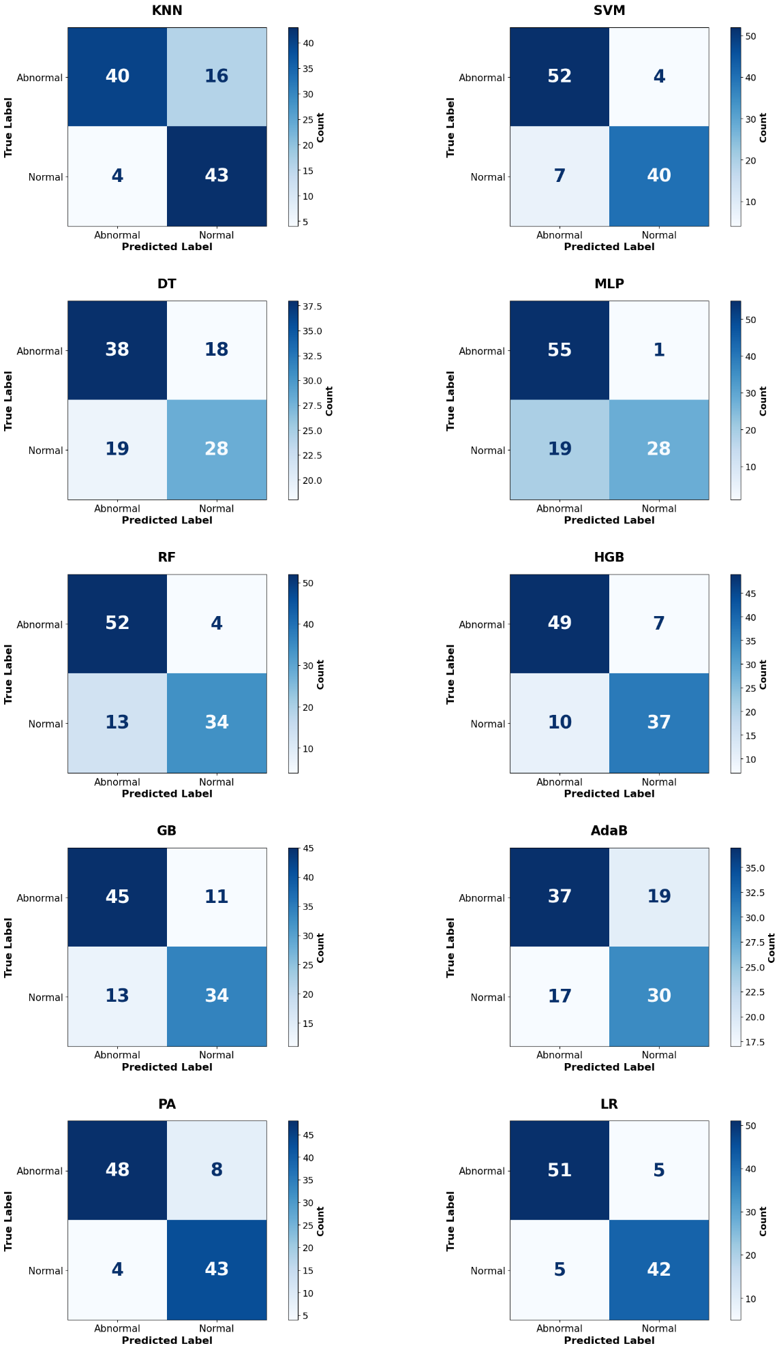